In [17]:
%%capture
from pathlib import Path

if Path.cwd().stem == "notebooks":
    %cd ..
    %load_ext autoreload
    %autoreload 2

In [18]:
import logging

import holoviews as hv
import hvplot.polars  # noqa
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from polars import col

from src.data.database_manager import DatabaseManager
from src.log_config import configure_logging
from src.plots.averages_over_stimulus_seeds import (
    average_over_stimulus_seeds,
    calculate_crosscorr_matrix,
    plot_averages_with_ci,
    plot_averages_with_ci_plt,
    plot_correlation_heatmap,
    plot_single_stimulus_seed,
)

configure_logging(
    ignore_libs=("Comm", "bokeh", "tornado", "matplotlib"),
)

pl.Config.set_tbl_rows(12)  # for 12 seeds
hv.output(widget_location="bottom", size=150)

In [19]:
db = DatabaseManager()

In [20]:
with db:
    df = db.get_trials("Explore_Data", exclude_problematic=True)

df = df.rename({"rating": "pain_rating", "pupil": "pupil_diameter"})

In [21]:
signals = [
    "temperature",
    "pain_rating",
    "pupil_diameter",
    "eda_tonic",
    "eda_phasic",
    "heart_rate",
]

averages = average_over_stimulus_seeds(
    df,
    signals,
    scaling="min_max",
    bin_size=0.1,
    confidence_level=0.95,
)

# Correlation matrix

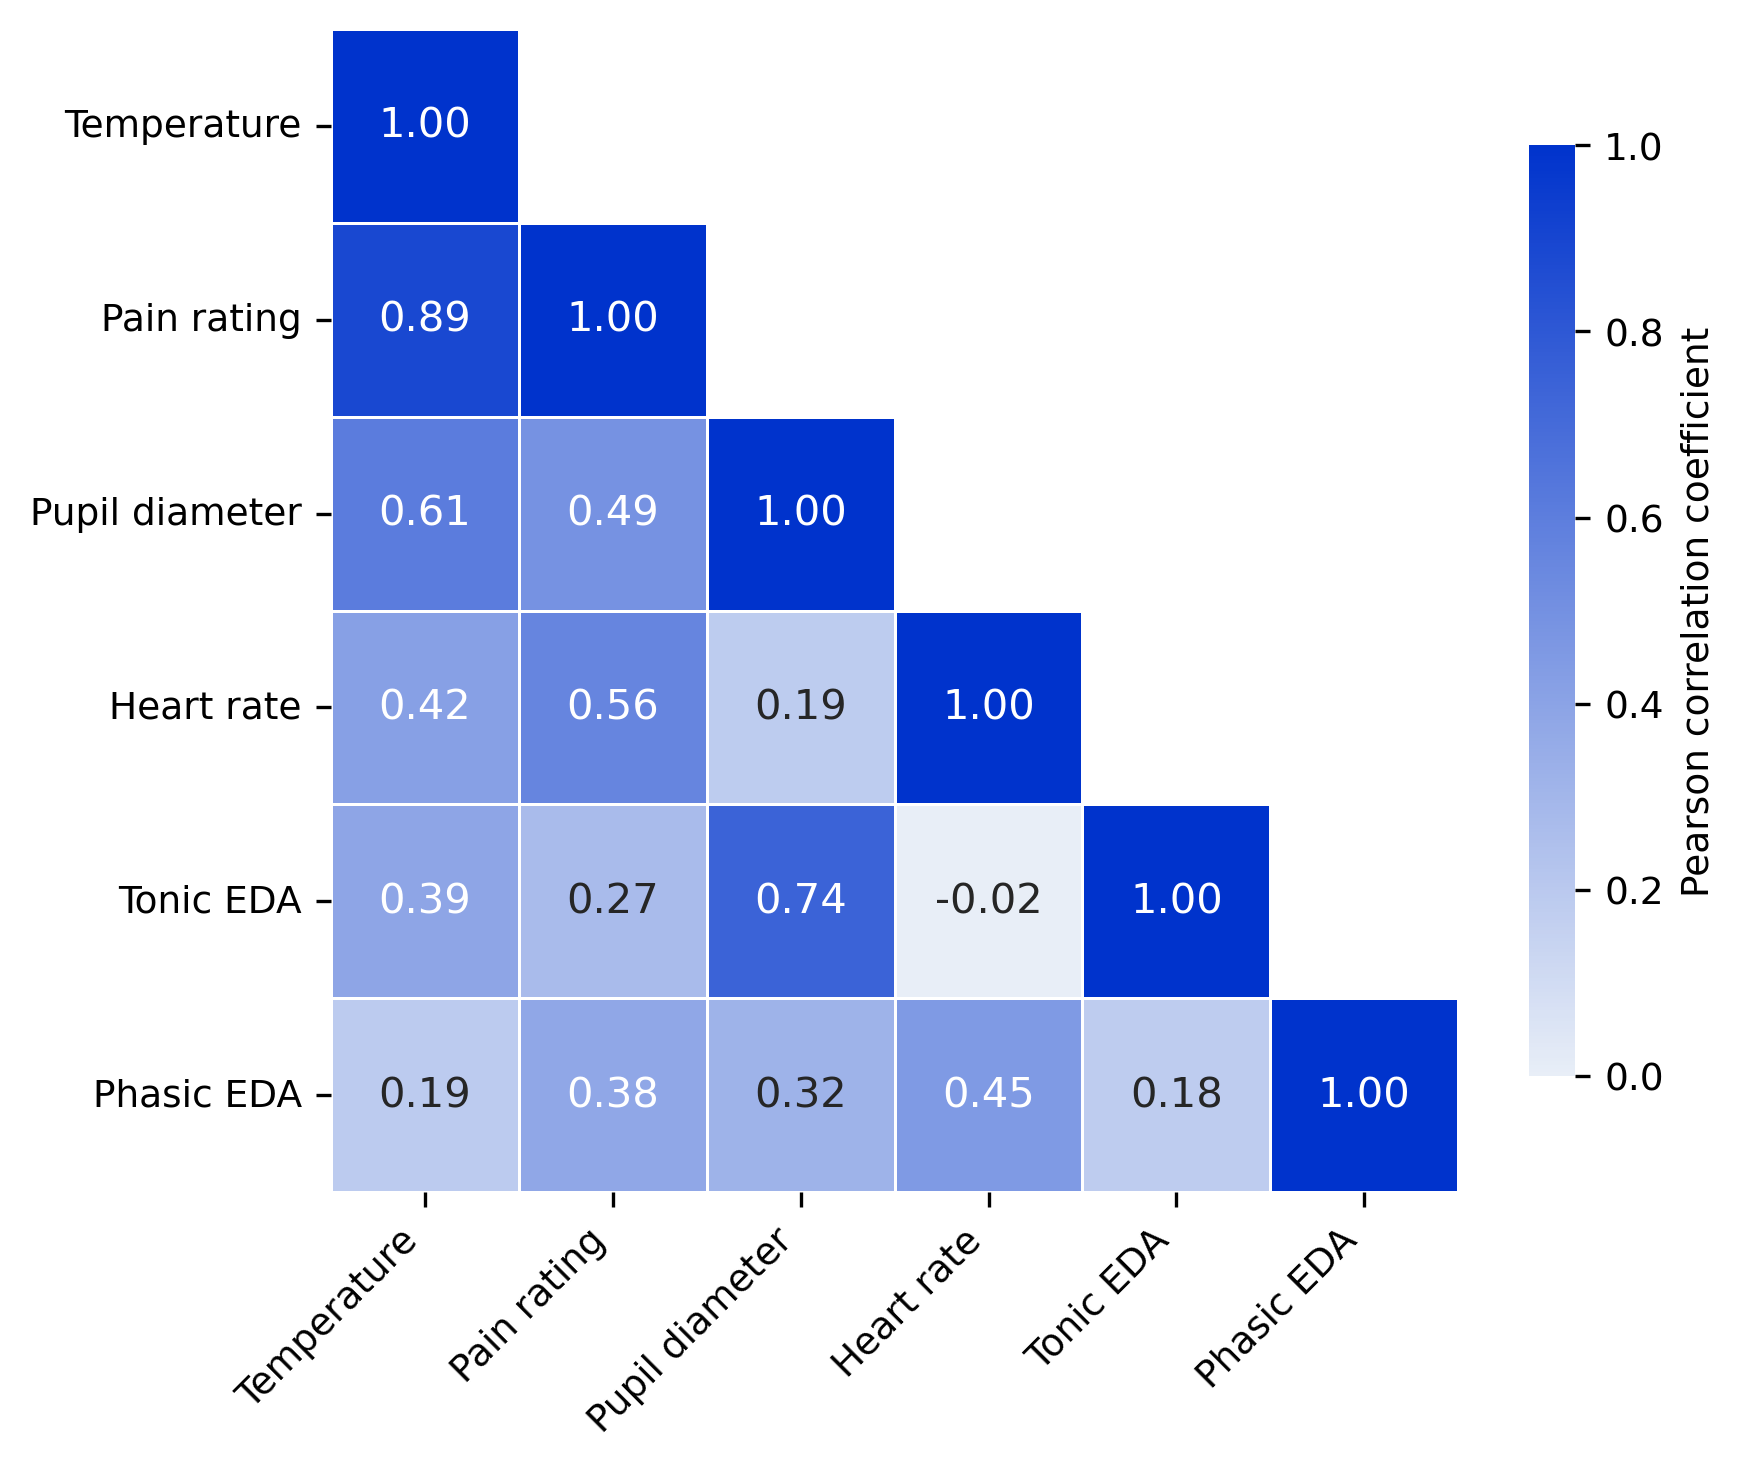

In [22]:
# without first 20 seconds
correlation_heatmap = plot_correlation_heatmap(averages, skip_first_n_seconds=20)

In [23]:
import os
from pathlib import Path

import holoviews as hv
import hvplot.polars  # noqa
import polars as pl
import tomllib
from dotenv import load_dotenv

from src.experiments.measurement.stimulus_generator import StimulusGenerator
from src.features.utils import to_describe
from src.log_config import configure_logging
from src.plots.plot_stimulus import (
    plot_stimulus,
    plot_stimulus_labels,
    plot_stimulus_matplotlib,
    plot_stimulus_with_labels,
)

load_dotenv()
FIGURE_DIR = Path(os.getenv("FIGURE_DIR"))

configure_logging(
    stream_level=logging.DEBUG,
    ignore_libs=["numexpr", "numba", "bokeh", "matplotlib", "tornado", "Comm"],
)

pl.Config.set_tbl_rows(12)  # for the 12 trials
hv.output(widget_location="bottom", size=130)

In [24]:
def load_configuration(file_path: str) -> dict:
    """Load configuration from a TOML file."""
    file_path = Path(file_path)
    with open(file_path, "rb") as file:
        return tomllib.load(file)


config = load_configuration("src/experiments/measurement/measurement_config.toml")[
    "stimulus"
]


In [25]:
config = {
    "seeds": config["seeds"],
    "sample_rate": config["sample_rate"],
    "half_cycle_num": config["half_cycle_num"],
    "period_range": config["period_range"],
    "amplitude_range": config["amplitude_range"],
    "inflection_point_range": config["inflection_point_range"],
    "shorten_expected_duration": config["shorten_expected_duration"],
    "major_decreasing_half_cycle_num": config["major_decreasing_half_cycle_num"],
    "major_decreasing_half_cycle_period": config["major_decreasing_half_cycle_period"],
    "major_decreasing_half_cycle_amplitude": config[
        "major_decreasing_half_cycle_amplitude"
    ],
    "major_decreasing_half_cycle_min_y_intercept": config[
        "major_decreasing_half_cycle_min_y_intercept"
    ],
    "plateau_num": config["plateau_num"],
    "plateau_duration": config["plateau_duration"],
    "plateau_percentile_range": config["plateau_percentile_range"],
    "prolonged_minima_num": config["prolonged_minima_num"],
    "prolonged_minima_duration": config["prolonged_minima_duration"],
}

dummy_participant = {
    "temperature_baseline": 47.0,
    "temperature_range": 1.5,  # VAS 0 - VAS 70
}


dummy_config = {
    "seeds": [1, 2, 3],
    "half_cycle_num": 2,
    "period_range": [2, 2],
    "major_decreasing_half_cycle_num": 0,
    "shorten_expected_duration": 0,
    "amplitude_range": [0.9, 1.0],
    "plateau_num": 0,
    "prolonged_minima_num": 0,
}

# Plot one random seed
config.update(dummy_participant)
stimulus = StimulusGenerator(config, debug=0, seed=467)


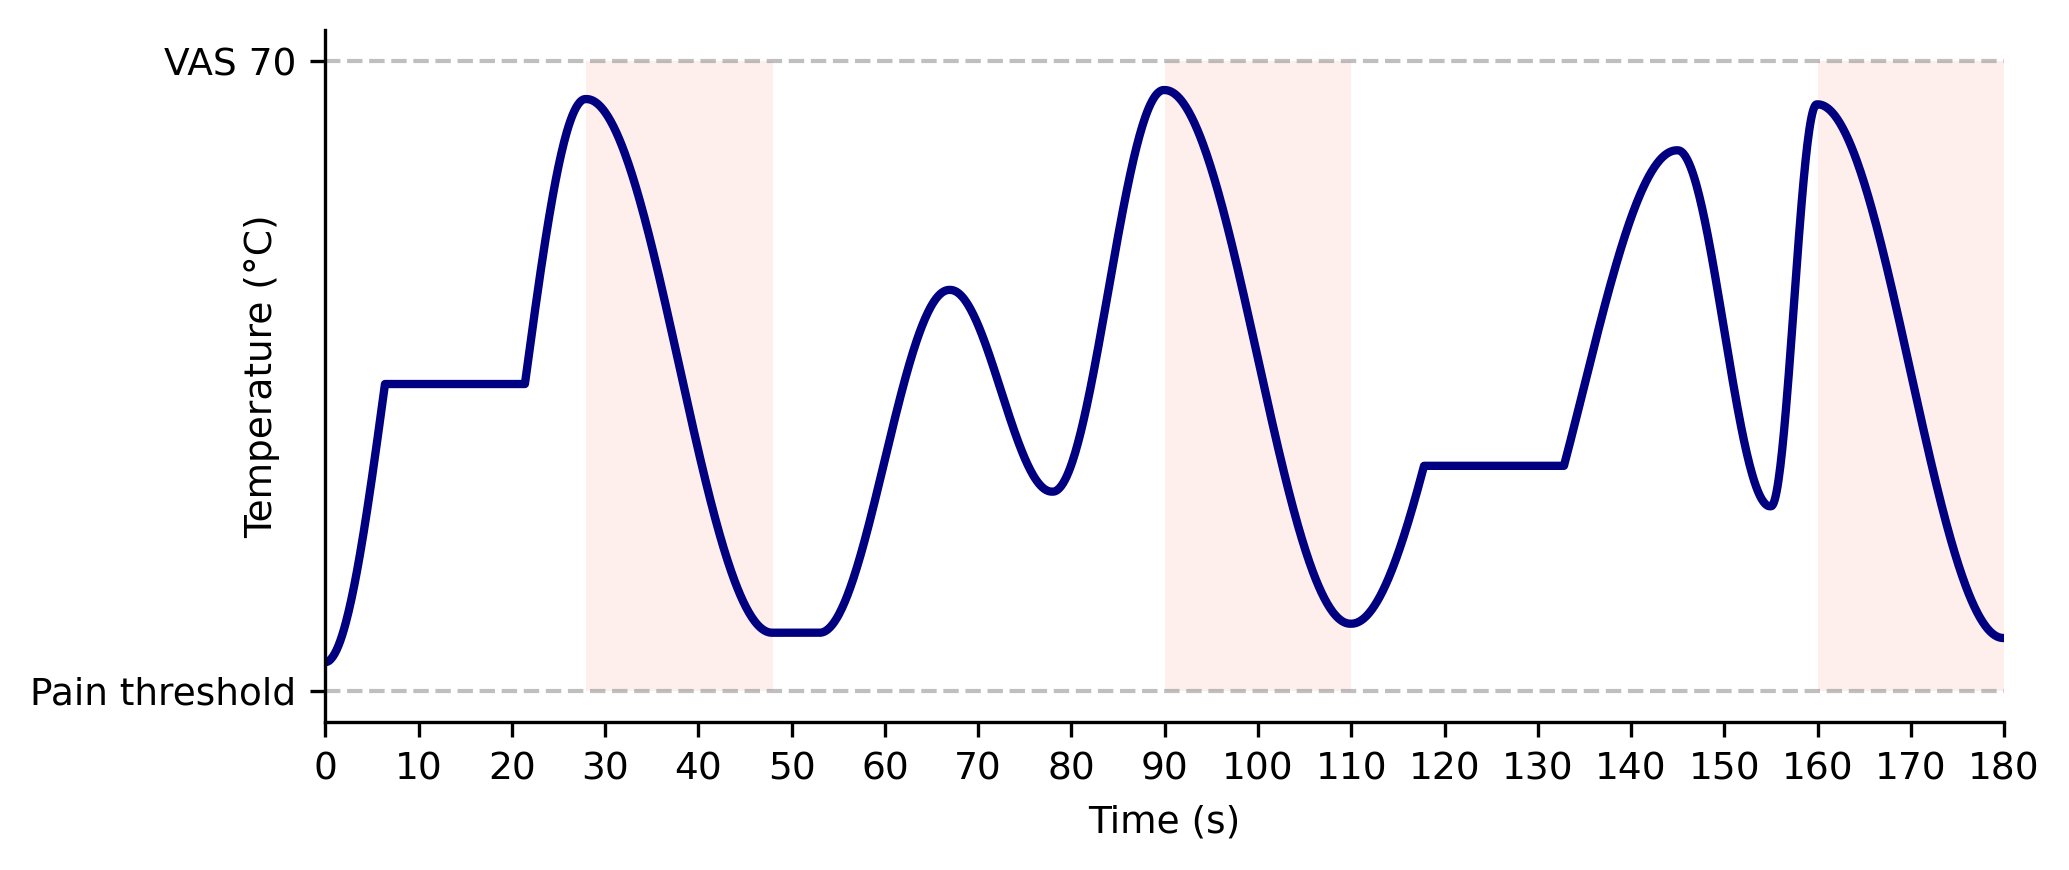

In [26]:
fig = plot_stimulus_matplotlib(stimulus, show_arrows=False)

In [27]:
import json
import logging
import os
from datetime import datetime
from pathlib import Path
from typing import Any

import joblib
from dotenv import load_dotenv

from src.log_config import configure_logging
from src.models.data_loader import create_dataloaders
from src.models.data_preparation import (
    expand_feature_list,
    load_data_from_database,
    prepare_data,
)
from src.models.main_config import RANDOM_SEED
from src.models.utils import load_model
from src.plots.model_inference import (
    analyze_test_dataset_for_one_stimulus,
    plot_prediction_confidence_heatmap,
)
from src.plots.model_performance import (
    create_performance_table,
    get_model_predictions,
    plot_multiple_roc_curves,
)
from src.plots.model_performance_per_participant import (
    aggregate_accuracy_stats,
    analyze_per_participant,
    plot_feature_accuracy_boxplot,
)

load_dotenv()
FIGURE_DIR = Path(os.getenv("FIGURE_DIR"))

plt.style.use("./src/plots/style.mplstyle")

feature_lists = [
    ["eda_raw"],
    ["heart_rate"],
    ["pupil"],
    ["eda_raw", "heart_rate"],
    ["eda_raw", "pupil"],
    ["eda_raw", "heart_rate", "pupil"],
    ["face"],
    ["face", "eda_raw", "heart_rate", "pupil"],
    ["eeg"],
    ["eeg", "eda_raw"],
    ["eeg", "face", "eda_raw", "heart_rate", "pupil"],
]
feature_lists = expand_feature_list(feature_lists)


class InferenceCache:
    """Lightweight cache for model inference results only."""

    def __init__(self, cache_dir: Path = Path(".cache/model_inference")):
        self.cache_dir = cache_dir
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def _get_model_timestamp(self, model_path: Path) -> str:
        """Extract timestamp from model filename."""
        filename = model_path.name
        try:
            parts = filename.split("_")
            if len(parts) >= 2:
                timestamp_part = parts[-1].replace(".pt", "")
                return timestamp_part
        except:
            pass
        return str(datetime.fromtimestamp(model_path.stat().st_mtime))

    def _get_cache_key(self, feature_list_str: str, cache_type: str, **kwargs) -> str:
        """Generate unique cache key including any additional parameters."""
        key_parts = [feature_list_str, cache_type]
        for k, v in sorted(kwargs.items()):
            if isinstance(v, (list, tuple)):
                v = "_".join(map(str, v))
            key_parts.append(f"{k}_{v}")
        return "_".join(key_parts)

    def _get_cache_path(self, cache_key: str) -> Path:
        """Get cache file path for a given cache key."""
        return (
            self.cache_dir / f"{cache_key}.joblib"
        )  # Changed extension from .pkl to .joblib

    def _is_cache_valid(self, feature_list_str: str, model_path: Path) -> bool:
        """Check if cached data is still valid based on model timestamp."""
        timestamp_file = self.cache_dir / f"{feature_list_str}_timestamp.txt"

        if not timestamp_file.exists():
            return False

        cached_timestamp = timestamp_file.read_text().strip()
        current_timestamp = self._get_model_timestamp(model_path)

        return cached_timestamp == current_timestamp

    def _update_timestamp(self, feature_list_str: str, model_path: Path):
        """Update the model timestamp for cache validation."""
        timestamp_file = self.cache_dir / f"{feature_list_str}_timestamp.txt"
        timestamp = self._get_model_timestamp(model_path)
        timestamp_file.write_text(timestamp)

    def get(self, feature_list_str: str, cache_type: str, **kwargs) -> Any:
        """Get cached data if available and valid."""
        cache_key = self._get_cache_key(feature_list_str, cache_type, **kwargs)
        cache_path = self._get_cache_path(cache_key)

        if cache_path.exists():
            try:
                data = joblib.load(cache_path)
                logging.debug(f"Cache hit: {cache_key}")
                return data
            except Exception as e:
                logging.warning(f"Failed to load cache {cache_key}: {e}")

        return None

    def set(self, feature_list_str: str, cache_type: str, data: Any, **kwargs):
        """Save data to cache."""
        cache_key = self._get_cache_key(feature_list_str, cache_type, **kwargs)
        cache_path = self._get_cache_path(cache_key)

        try:
            # Use joblib instead of pickle
            joblib.dump(data, cache_path, compress=3)  # Use compression level 3
            logging.debug(f"Cached: {cache_key}")
        except Exception as e:
            logging.warning(f"Failed to cache {cache_key}: {e}")

    def clear(self, feature_list_str: str = None):
        """Clear cache for specific feature list or all."""
        if feature_list_str:
            pattern = f"{feature_list_str}_*"
            for file in self.cache_dir.glob(pattern):
                file.unlink()
                logging.info(f"Removed cache: {file.name}")
        else:
            for file in self.cache_dir.glob("*.pkl"):
                file.unlink()
            for file in self.cache_dir.glob("*.txt"):
                file.unlink()
            logging.info("Cleared all cache")


cache = InferenceCache()


def load_model_and_data(feature_list: list, feature_list_str: str) -> tuple:
    """Load model and prepare data - no caching, direct loading."""
    # Load model
    json_path = Path(f"results/experiment_{feature_list_str}/results.json")
    dictionary = json.loads(json_path.read_text())
    model_path = Path(dictionary["overall_best"]["model_path"].replace("\\", "/"))

    logging.info(f"Loading model for {feature_list_str}")
    (
        model,
        feature_list_loaded,
        sample_duration_ms,
        intervals,
        label_mapping,
        offsets_ms,
    ) = load_model(model_path, device="cpu")

    # Load data
    logging.info(f"Loading data for {feature_list_str}")
    df = load_data_from_database(feature_list)

    # Prepare data
    _, _, _, _, X_train_val, y_train_val, X_test, y_test = prepare_data(
        df=df,
        feature_list=feature_list_loaded,
        sample_duration_ms=sample_duration_ms,
        intervals=intervals,
        label_mapping=label_mapping,
        offsets_ms=offsets_ms,
        random_seed=RANDOM_SEED,
    )

    # Get test groups
    test_groups = prepare_data(
        df=df,
        feature_list=feature_list_loaded,
        sample_duration_ms=sample_duration_ms,
        intervals=intervals,
        label_mapping=label_mapping,
        offsets_ms=offsets_ms,
        random_seed=RANDOM_SEED,
        only_return_test_groups=True,
    )

    # Create dataloaders
    train_loader, test_loader = create_dataloaders(
        X_train_val, y_train_val, X_test, y_test, batch_size=64
    )

    model_config = {
        "feature_list": feature_list_loaded,
        "sample_duration_ms": sample_duration_ms,
        "intervals": intervals,
        "label_mapping": label_mapping,
        "offsets_ms": offsets_ms,
        "model_name": model.__class__.__name__,
        "model_path": model_path,
    }

    return model, model_config, df, test_loader, test_groups


def model_inference(
    cache: InferenceCache,
    classification_threshold: float = 0.9,
    step_size: int = 1000,
    only_non_decreases: bool = False,
):
    """Run model inference analysis with caching of results only."""
    config_path = Path("src/experiments/measurement/measurement_config.toml")
    with open(config_path, "rb") as file:
        config = tomllib.load(file)
    stimulus_seeds = config["stimulus"]["seeds"]
    logging.info(f"Using seeds for stimulus generation: {stimulus_seeds}")

    for feature_list in feature_lists:
        feature_list_str = "_".join(feature_list)

        # Check cache validity first
        json_path = Path(f"results/experiment_{feature_list_str}/results.json")
        dictionary = json.loads(json_path.read_text())
        model_path = Path(dictionary["overall_best"]["model_path"].replace("\\", "/"))

        # Try to get cached inference results
        cache_valid = cache._is_cache_valid(feature_list_str, model_path)

        if cache_valid:
            cached_results = cache.get(
                feature_list_str,
                "inference_probabilities",
                seeds=tuple(stimulus_seeds),
                step_size=step_size,
            )

            if cached_results:
                logging.info(f"Using cached inference results for {feature_list_str}")
                all_probabilities = cached_results["probabilities"]
                sample_duration_ms = cached_results["sample_duration_ms"]
            else:
                cached_results = None
        else:
            cached_results = None

        if cached_results is None:
            # Load model and data (not cached)
            model, model_config, df, _, test_groups = load_model_and_data(
                feature_list, feature_list_str
            )

            test_ids = np.unique(test_groups)

            # Analyze the entire test dataset
            all_probabilities = {}

            for stimulus_seed in stimulus_seeds:
                probabilities, _ = analyze_test_dataset_for_one_stimulus(
                    df,
                    model,
                    model_config["feature_list"],
                    test_ids,
                    stimulus_seed,
                    model_config["sample_duration_ms"],
                    step_size,
                )
                all_probabilities[stimulus_seed] = probabilities

            # Cache the results
            cache._update_timestamp(feature_list_str, model_config["model_path"])
            cache.set(
                feature_list_str,
                "inference_probabilities",
                {
                    "probabilities": all_probabilities,
                    "sample_duration_ms": model_config["sample_duration_ms"],
                },
                seeds=tuple(stimulus_seeds),
                step_size=step_size,
            )

            sample_duration_ms = model_config["sample_duration_ms"]

        # Plot all available stimuli
        fig = plot_prediction_confidence_heatmap(
            all_probabilities,
            sample_duration_ms,
            classification_threshold=classification_threshold,
            ncols=2,
            figure_size=(7, 2),
            stimulus_scale=0.5,
            stimulus_linewidth=1.5,
            only_decreases=not only_non_decreases,
            only_non_decreases=only_non_decreases,
            step_size=step_size,
        )

        # Save the figure
        fig_path = FIGURE_DIR / f"model_inference_{feature_list_str}.png"
        fig.savefig(fig_path, bbox_inches="tight", dpi=300)
        plt.close(fig)
        logging.info(f"Saved figure to {fig_path}")


def model_performance_per_participant(cache: InferenceCache):
    """Analyze model performance per participant with result caching."""
    results = {}

    for feature_list in feature_lists:
        feature_list_str = "_".join(feature_list)

        # Check cache validity
        json_path = Path(f"results/experiment_{feature_list_str}/results.json")
        dictionary = json.loads(json_path.read_text())
        model_path = Path(dictionary["overall_best"]["model_path"].replace("\\", "/"))

        # Try to get cached results
        if cache._is_cache_valid(feature_list_str, model_path):
            cached_result = cache.get(feature_list_str, "per_participant_results")
            if cached_result is not None and not cached_result.is_empty():
                logging.info(
                    f"Using cached per-participant results for {feature_list_str}"
                )
                results[feature_list_str] = cached_result
                continue

        # Load and analyze if not cached
        model, model_config, _, test_loader, test_groups = load_model_and_data(
            feature_list, feature_list_str
        )

        result_df = analyze_per_participant(
            model,
            test_loader,
            test_groups,
            threshold=0.50,
        )
        results[feature_list_str] = result_df

        # Cache the result
        cache._update_timestamp(feature_list_str, model_path)
        cache.set(feature_list_str, "per_participant_results", result_df)

    # Create plots
    feature_set_acc, _ = plot_feature_accuracy_boxplot(results, figsize=(10, 6))

    # Create accuracy table
    accuracy_stats = aggregate_accuracy_stats(
        results, include_ci=False, sort_by_avg=False
    )

    # Save results
    return feature_set_acc


def model_performance(cache: InferenceCache):
    """Analyze overall model performance with prediction caching."""
    results = {}
    winning_models = {}

    for feature_list in feature_lists:
        feature_list_str = "_".join(feature_list)

        # Check cache validity
        json_path = Path(f"results/experiment_{feature_list_str}/results.json")
        dictionary = json.loads(json_path.read_text())
        model_path = Path(dictionary["overall_best"]["model_path"].replace("\\", "/"))

        # Try to get cached predictions
        if cache._is_cache_valid(feature_list_str, model_path):
            cached_predictions = cache.get(feature_list_str, "test_predictions")
            if cached_predictions:
                logging.info(f"Using cached predictions for {feature_list_str}")
                results[feature_list_str] = (
                    cached_predictions["probs"],
                    cached_predictions["y_true"],
                )
                winning_models[feature_list_str] = {
                    feature_list_str: cached_predictions["model_name"]
                }
                continue

        # Load and predict if not cached
        model, model_config, _, test_loader, _ = load_model_and_data(
            feature_list, feature_list_str
        )

        winning_models[feature_list_str] = {
            feature_list_str: model_config["model_name"]
        }

        probs, y_true = get_model_predictions(model, test_loader)
        results[feature_list_str] = (probs, y_true)

        # Cache the predictions
        cache._update_timestamp(feature_list_str, model_path)
        cache.set(
            feature_list_str,
            "test_predictions",
            {
                "probs": probs,
                "y_true": y_true,
                "model_name": model_config["model_name"],
            },
        )

    # Create plots and tables
    roc_curves = plot_multiple_roc_curves(results)
    return roc_curves


22:26:36 | DEBUG   | root | Cache hit: eda_raw_test_predictions
22:26:36 | INFO    | root | Using cached predictions for eda_raw
22:26:36 | DEBUG   | root | Cache hit: heart_rate_test_predictions
22:26:36 | INFO    | root | Using cached predictions for heart_rate
22:26:36 | DEBUG   | root | Cache hit: pupil_test_predictions
22:26:36 | INFO    | root | Using cached predictions for pupil
22:26:36 | DEBUG   | root | Cache hit: eda_raw_heart_rate_test_predictions
22:26:36 | INFO    | root | Using cached predictions for eda_raw_heart_rate
22:26:36 | DEBUG   | root | Cache hit: eda_raw_pupil_test_predictions
22:26:36 | INFO    | root | Using cached predictions for eda_raw_pupil
22:26:36 | DEBUG   | root | Cache hit: eda_raw_heart_rate_pupil_test_predictions
22:26:36 | INFO    | root | Using cached predictions for eda_raw_heart_rate_pupil
22:26:36 | DEBUG   | root | Cache hit: brow_furrow_cheek_raise_mouth_open_nose_wrinkle_upper_lip_raise_test_predictions
22:26:36 | INFO    | root | Using ca

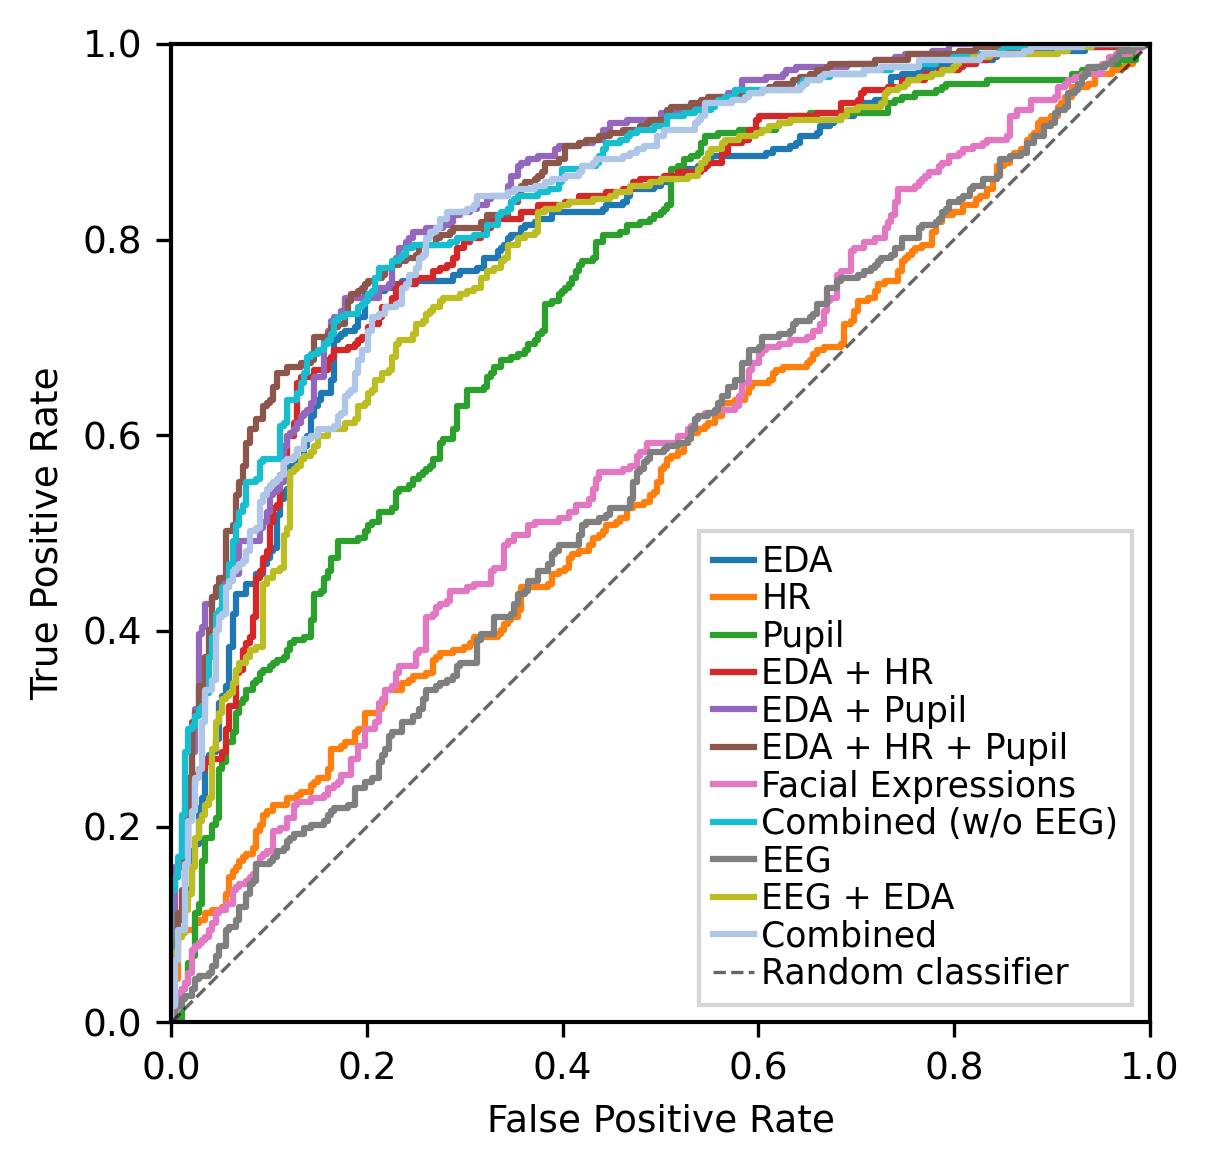

In [28]:
model_performance(cache);


In [29]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

from src.plots.plot_seed_stability import (
    extract_final_test_accuracies,
    load_results,
    plot_hist,
    summarize,
)

load_dotenv()


True

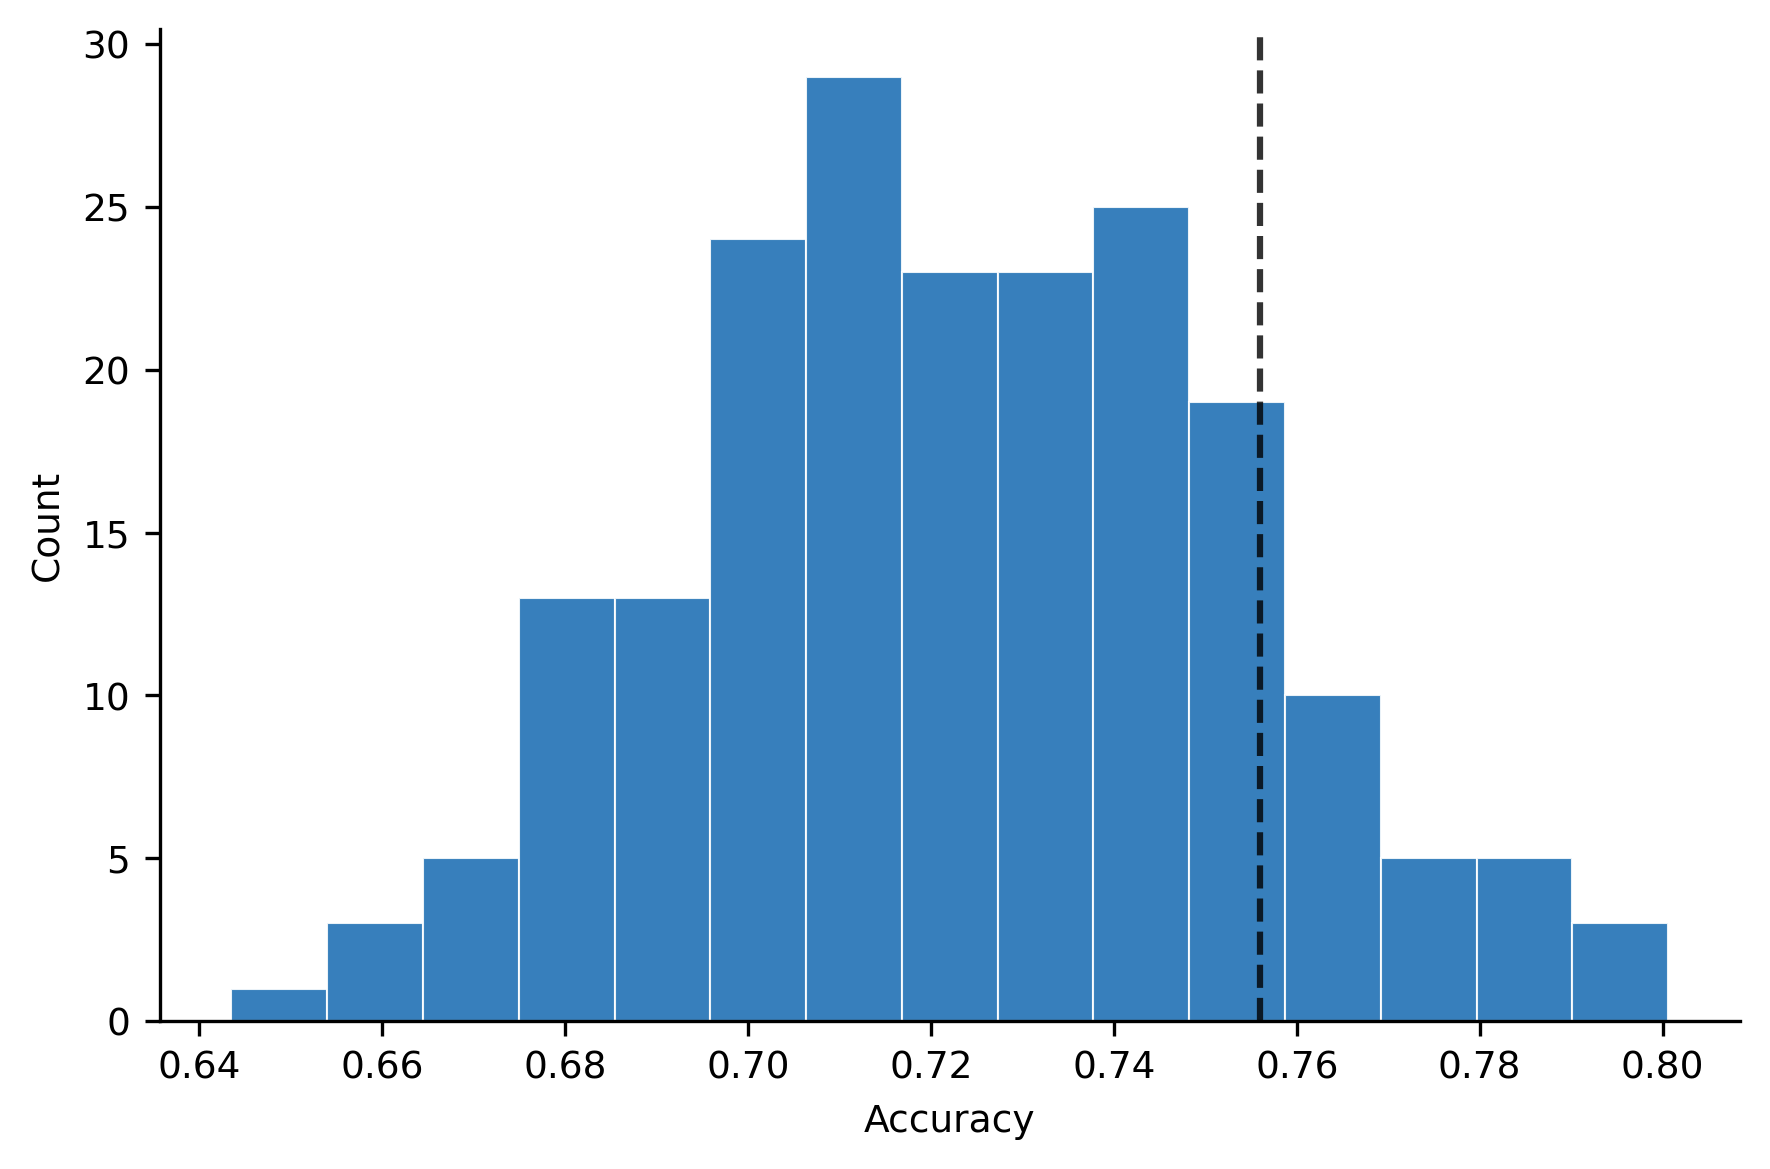

In [30]:
acc_42 = 0.756
data = load_results("results/experiment_eda_raw_heart_rate/stability_results.json")
vals = extract_final_test_accuracies(data)
fig = plot_hist(vals, bins=15, vline=acc_42)
fig.savefig(FIGURE_DIR / "stability_eda_hr.png", dpi=300, bbox_inches="tight")


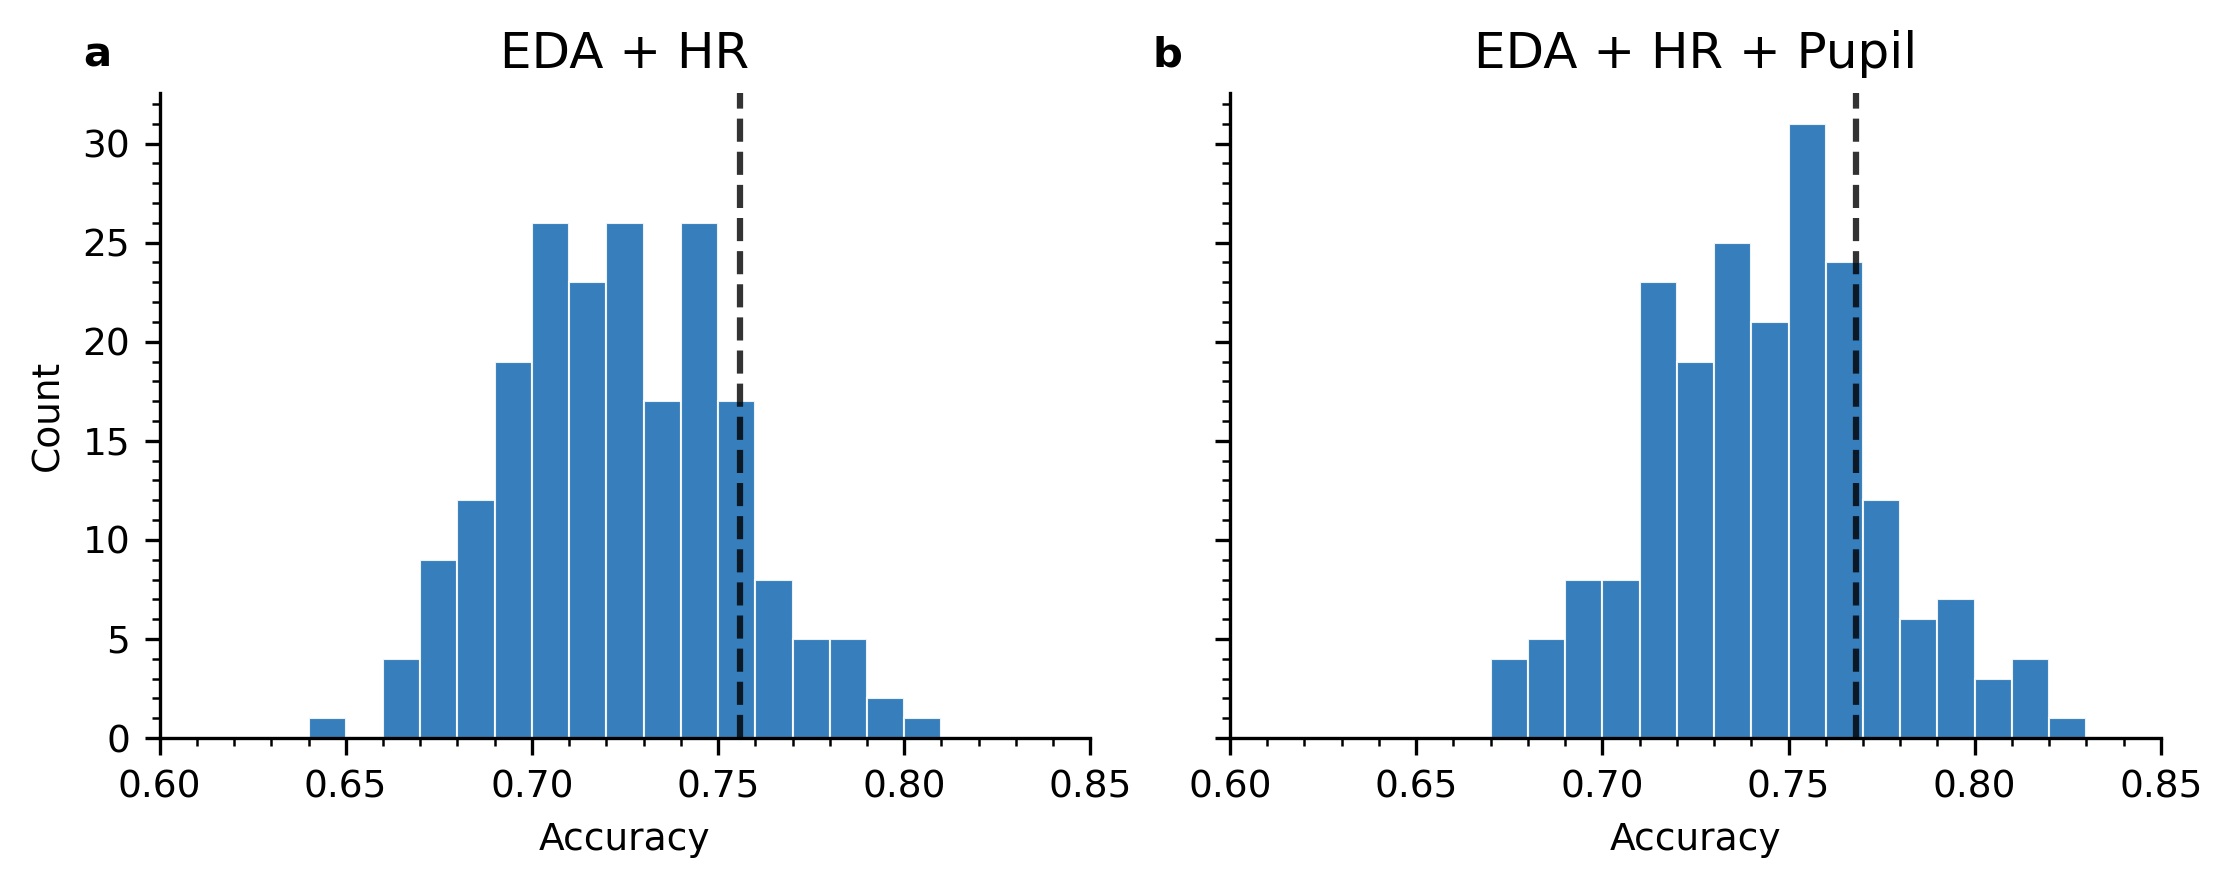

In [31]:
# Combined histogram figure with panel labels a and b (outside axes, original style)
acc1 = 0.756
data1 = load_results("results/experiment_eda_raw_heart_rate/stability_results.json")
vals1 = extract_final_test_accuracies(data1)

acc2 = 0.768
data2 = load_results(
    "results/experiment_eda_raw_heart_rate_pupil/stability_results.json"
)
vals2 = extract_final_test_accuracies(data2)

# Shared bins for fair comparison (15 bins) — align to snapped x-limits
data_min = float(min(min(vals1), min(vals2)))
data_max = float(max(max(vals1), max(vals2)))

# Snap limits to neat 0.05 steps
step = 0.05
xmin = np.floor(data_min / step) * step
xmax = np.ceil(data_max / step) * step

bin_width = 0.01
n_bins = int(np.round((xmax - xmin) / bin_width))
bins = np.linspace(xmin, xmax, n_bins + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Ensure both panels share identical limits
for ax in axes:
    ax.set_xlim(xmin, xmax)


def _hist_on_ax(ax, vals, vline=None, title=None):
    ax.hist(
        vals,
        bins=bins,
        color="#2171b5",
        edgecolor="white",
        alpha=0.9,
        linewidth=0.5,
    )
    # Match spines from plot_hist
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    if vline is not None:
        ax.axvline(vline, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    if title:
        ax.set_title(title)
    ax.set_xlabel("Accuracy")
    # x-ticks: major every 0.05, minor every 0.01 (no labels on minor)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.01))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", which="major", length=4)
    ax.tick_params(axis="x", which="minor", length=2)


# Panel a
_hist_on_ax(axes[0], vals1, vline=acc1, title="EDA + HR")
axes[0].set_ylabel("Count")

# Panel b
_hist_on_ax(axes[1], vals2, vline=acc2, title="EDA + HR + Pupil")

# Layout first, then place labels using final axes positions
plt.tight_layout()
fig.subplots_adjust(left=0.13, top=0.9, wspace=0.15)

bbox0 = axes[0].get_position()
bbox1 = axes[1].get_position()
pad_x, pad_y = 0.02, 0.02  # move left of ticks and above axes
fig.text(
    bbox0.x0 - pad_x, bbox0.y1 + pad_y, "a", ha="right", va="bottom", fontweight="bold"
)
fig.text(
    bbox1.x0 - pad_x, bbox1.y1 + pad_y, "b", ha="right", va="bottom", fontweight="bold"
)

fig.savefig(FIGURE_DIR / "stability_combined.png", dpi=300, bbox_inches="tight")

22:26:37 | DEBUG   | root | Cache hit: eda_raw_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for eda_raw
22:26:37 | DEBUG   | root | Cache hit: heart_rate_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for heart_rate
22:26:37 | DEBUG   | root | Cache hit: pupil_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for pupil
22:26:37 | DEBUG   | root | Cache hit: eda_raw_heart_rate_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for eda_raw_heart_rate
22:26:37 | DEBUG   | root | Cache hit: eda_raw_pupil_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for eda_raw_pupil
22:26:37 | DEBUG   | root | Cache hit: eda_raw_heart_rate_pupil_per_participant_results
22:26:37 | INFO    | root | Using cached per-participant results for eda_raw_heart_rate_pupil
22:26:37 | DEBUG   | root | Cache hit: bro

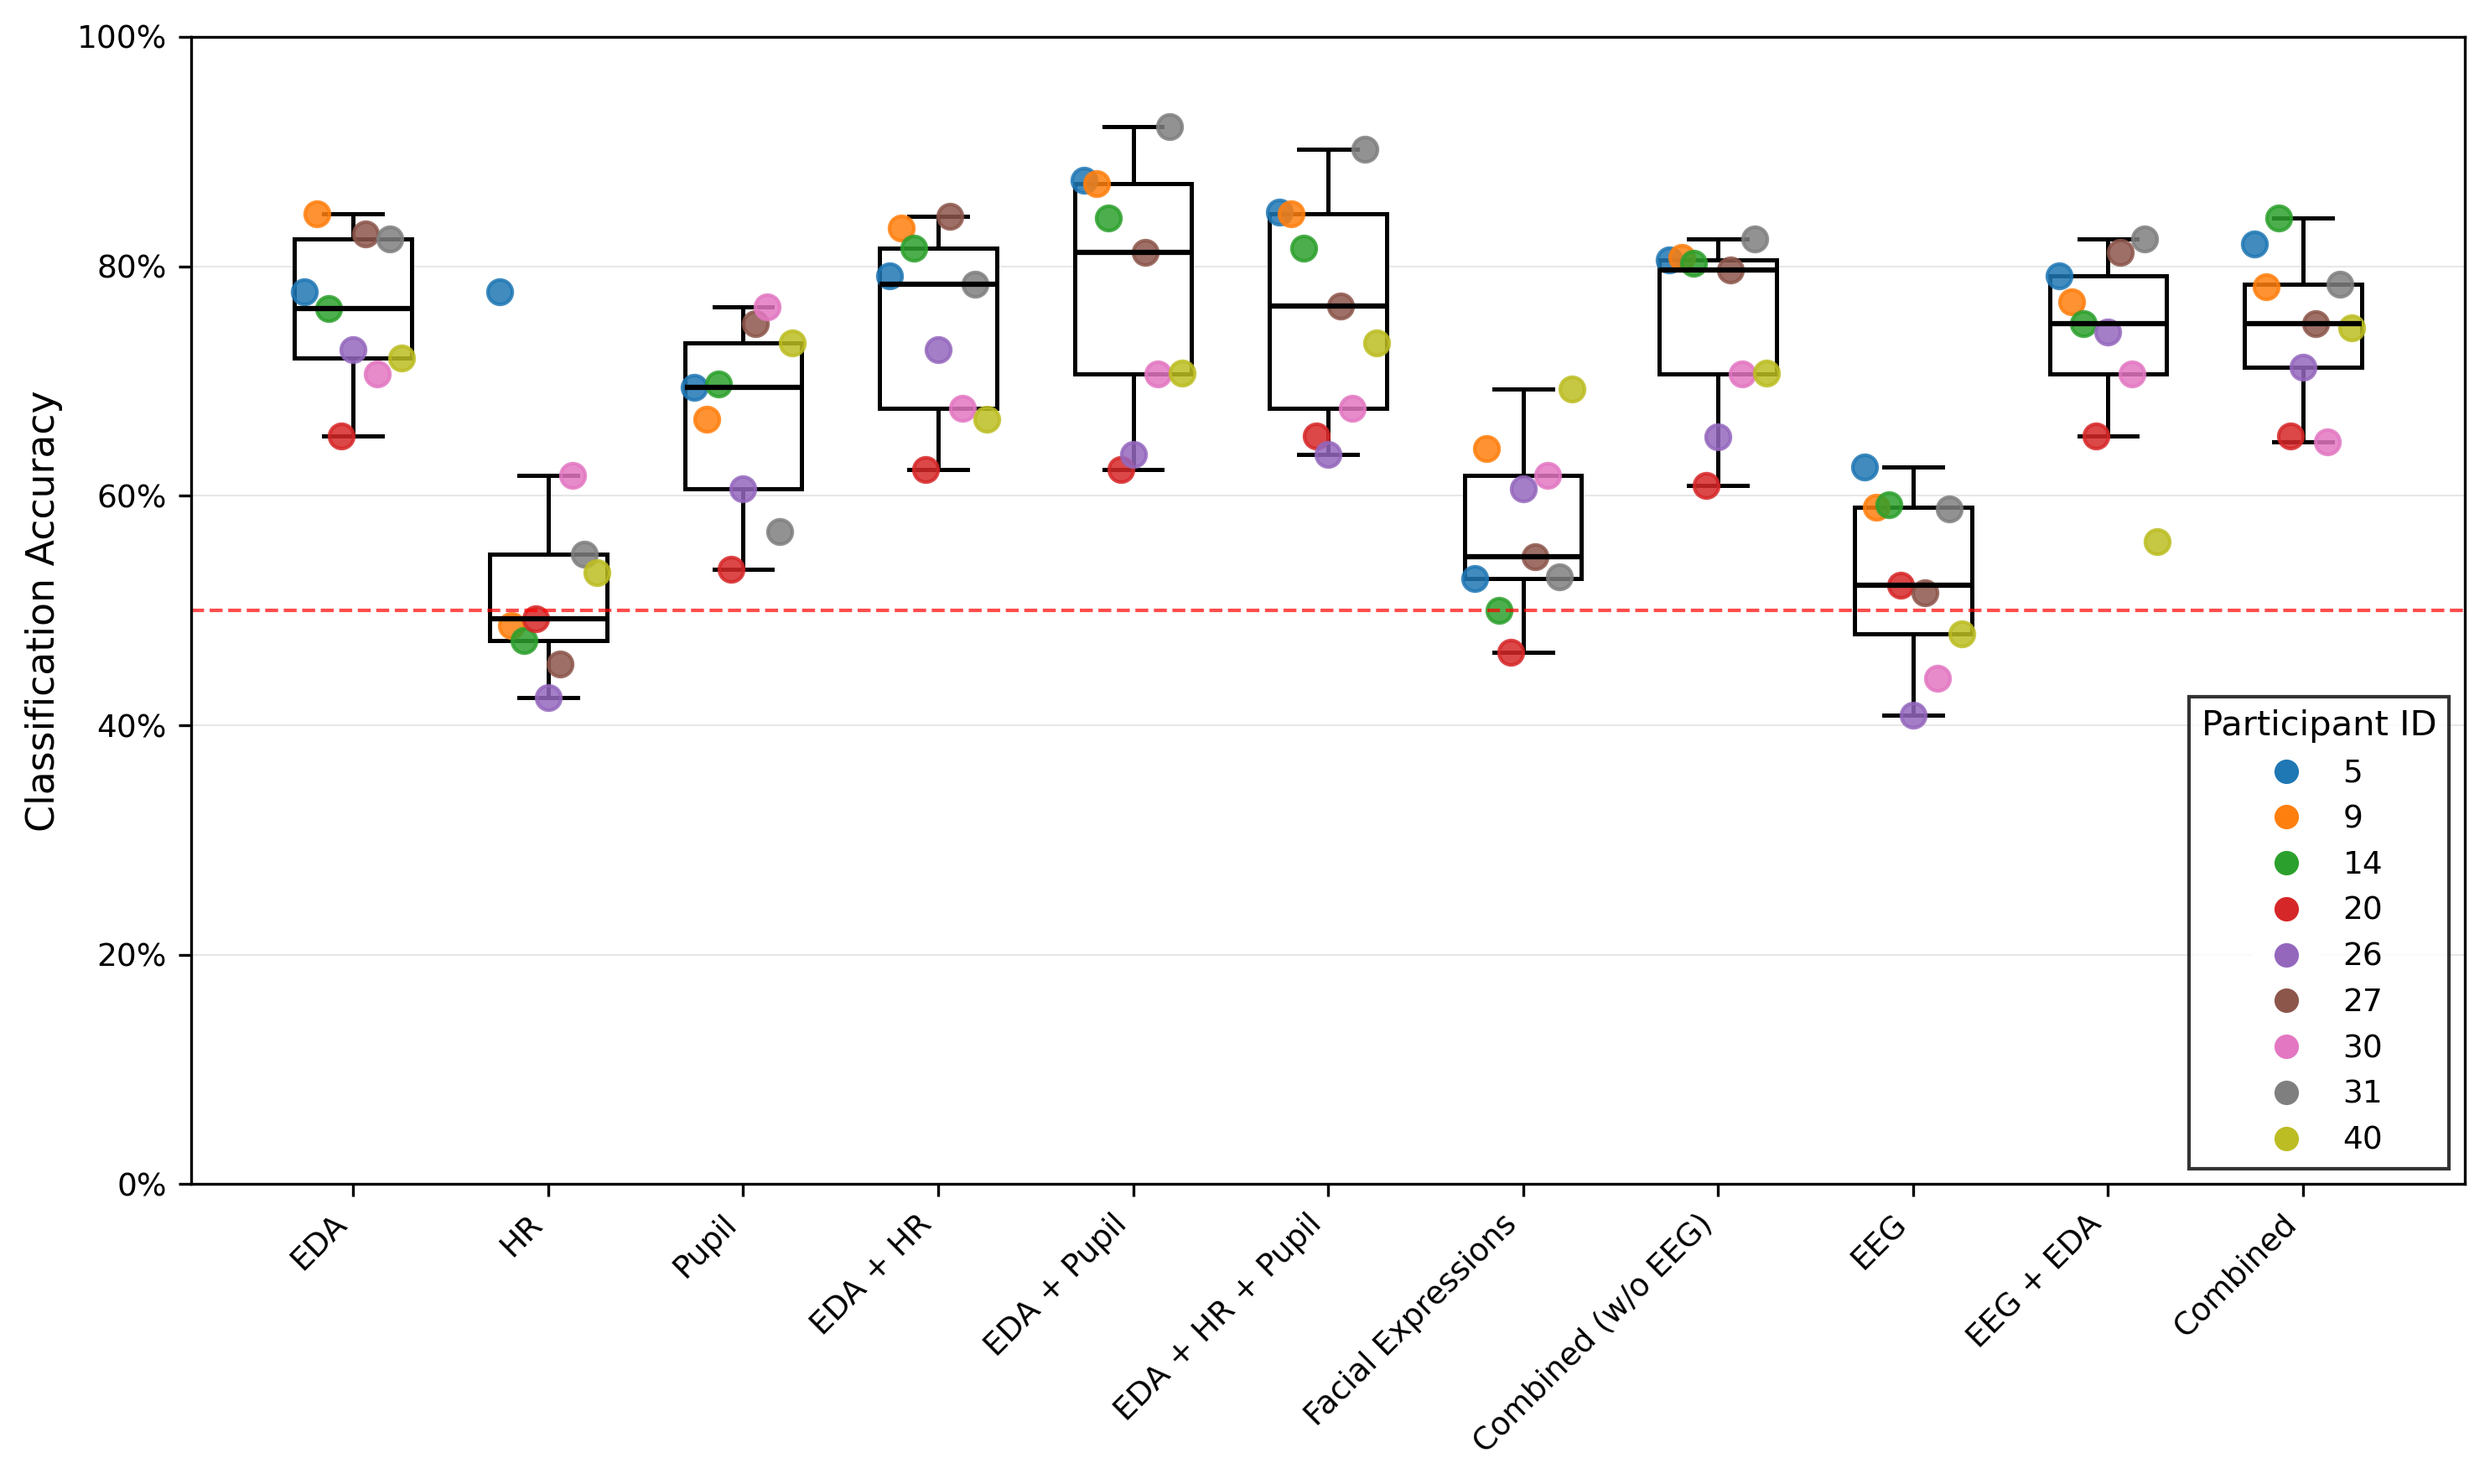

In [32]:
model_performance_per_participant(cache);
